In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gg = pd.read_csv('2026-05-02_golden_globes_genre.csv')

In [3]:
gg_counts = gg.groupby(['year','genre']).size().unstack(fill_value=0)

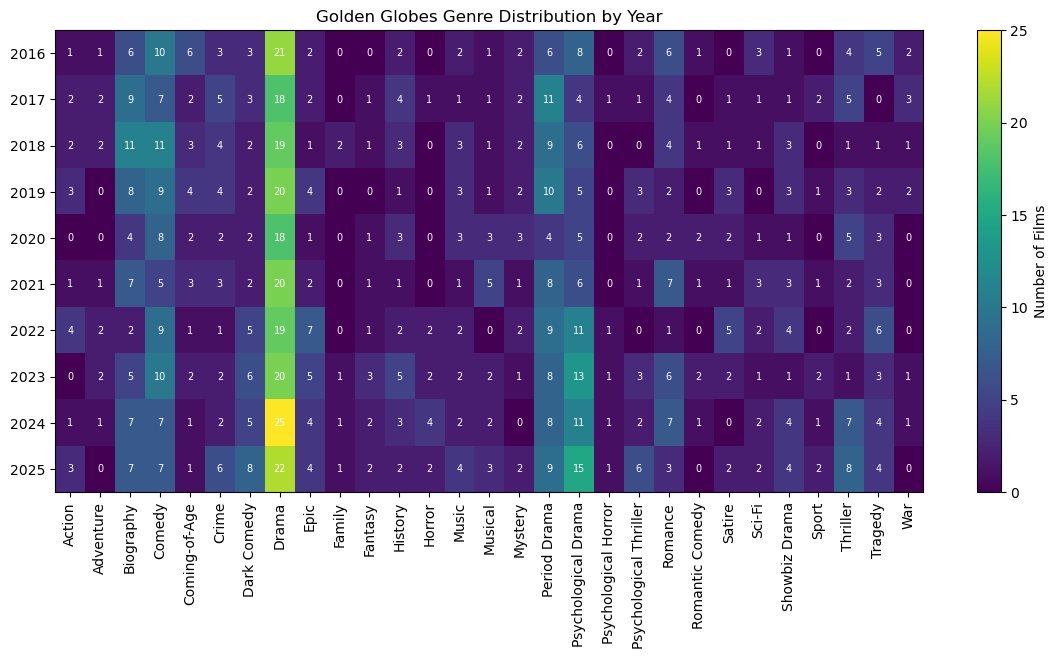

In [4]:
gg_filtered = gg_counts.loc[
    :, gg_counts.sum() >=5
    ]
fig, ax = plt.subplots(figsize = (14,6))
heatmap = ax.imshow(gg_filtered, aspect='auto')

ax.set_xticks(range(len(gg_filtered.columns)))
ax.set_yticks(range(len(gg_filtered.index)))
ax.set_xticklabels(gg_filtered.columns, rotation=90)
ax.set_yticklabels(gg_filtered.index)

for i, year in enumerate(gg_filtered.index):
    for j, genre in enumerate(gg_filtered.columns):
        ax.text(j, i, gg_filtered.loc[year, genre],
                ha="center", va="center", fontsize=7, color='white')

ax.set_title('Golden Globes Genre Distribution by Year')
plt.colorbar(heatmap, ax=ax, label= 'Number of Films')
fig.savefig('globesheatmap.jpg')

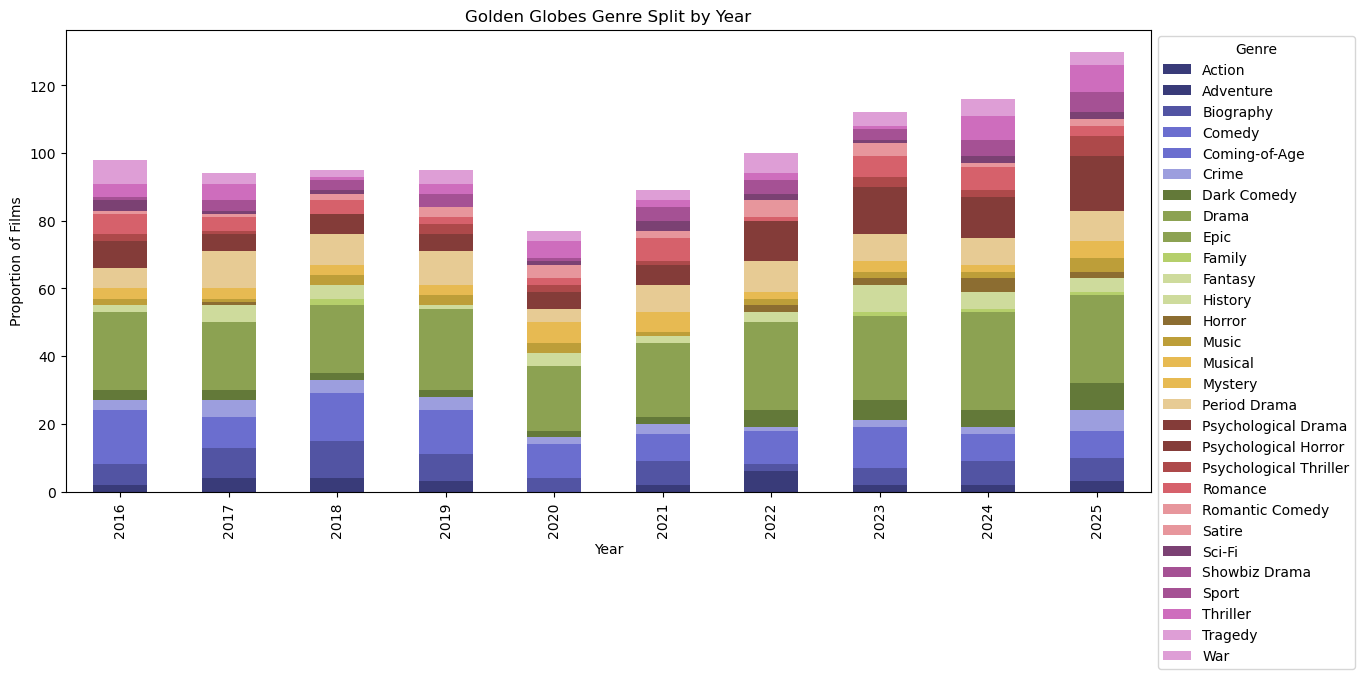

In [5]:
ax = gg_filtered.plot(kind='bar', figsize=(14,6),stacked=True,colormap='tab20b')
ax.set_title('Golden Globes Genre Split by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Films')
ax.legend(title='Genre',loc='upper left', bbox_to_anchor=(1,1))
fig.savefig('globesstackedbar.jpg')

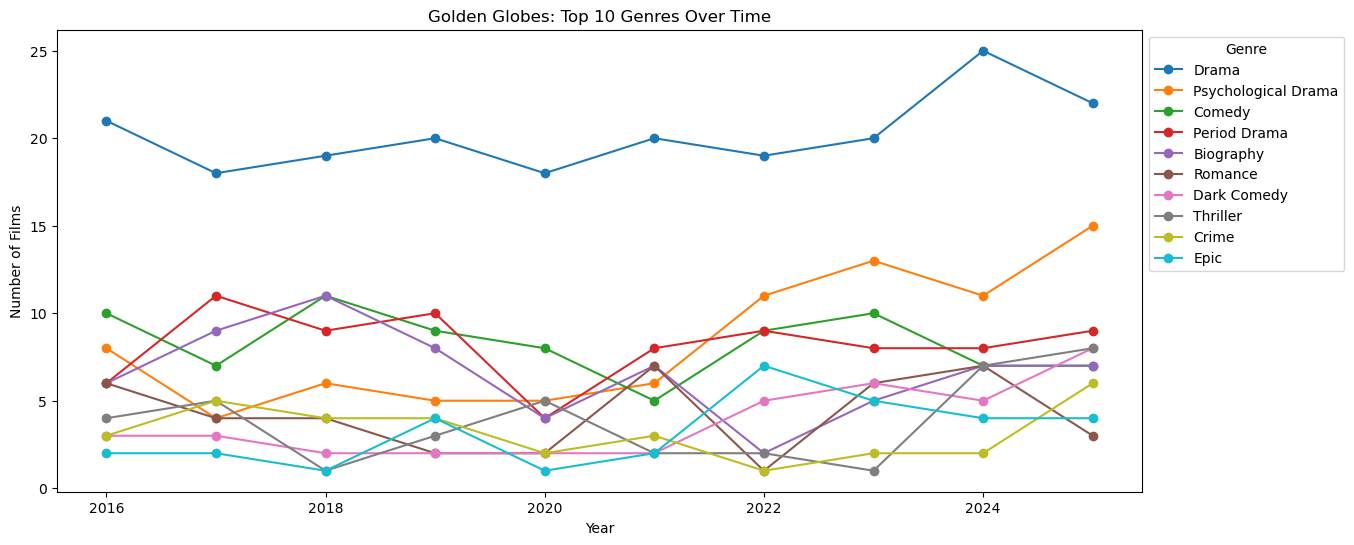

In [6]:
top_genres = gg_filtered.sum().nlargest(10).index
fig, ax = plt.subplots(figsize=(14,6))

for i in top_genres:
    ax.plot(
        gg_filtered.index,
        gg_filtered[i],
        marker='o',
        label=i)
ax.set_title('Golden Globes: Top 10 Genres Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Films')
ax.legend(title='Genre', bbox_to_anchor=(1,1), loc='upper left')
fig.savefig('globeslinegraph.jpg')

In [7]:
gg_filtered = gg_filtered.sort_index()
percent_changes = {}
for col in gg_filtered:
    firstval = gg_filtered[col].iloc[0]
    lastval = gg_filtered[col].iloc[-1]
    if firstval == 0:
        percent_changes[col] = None
    else:
        percent_changes[col] = ((lastval - firstval)/firstval) *100  

In [8]:
percent = pd.Series(percent_changes)

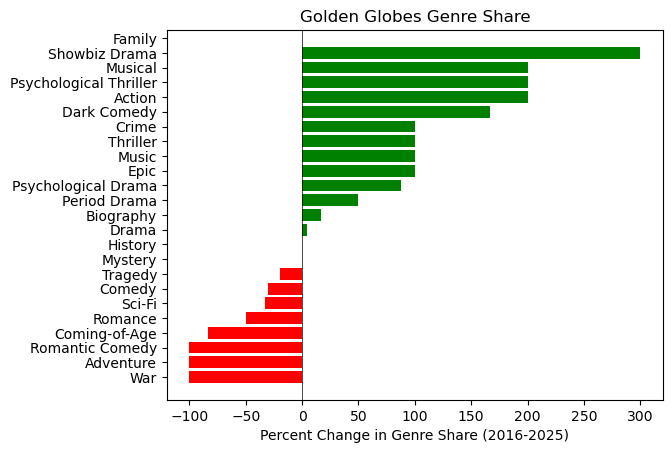

In [9]:
percent = percent.sort_values(ascending=True)

fig, ax = plt.subplots()
colors = ['green' if val >=0 else 'red' for val in percent.values]
bars = ax.barh(percent.index, percent.values, color=colors)
for bar, val in zip(bars, percent.values):
    sign = '+' if val >=0 else '-'
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Golden Globes Genre Share')
ax.set_xlabel('Percent Change in Genre Share (2016-2025)')
fig.savefig('globespercentchange.jpg')